In [1]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

X shape: (2000, 2)
First 5 X:
 [[ 1.7765071   0.19275202]
 [ 0.39780872  0.93039011]
 [ 0.49530794 -0.31832132]
 [-0.94894379  0.16301974]
 [ 0.48495693 -0.33816023]]
Mean of X: [0.49921708 0.2507061 ]
Std of X: [0.87202523 0.50447609]


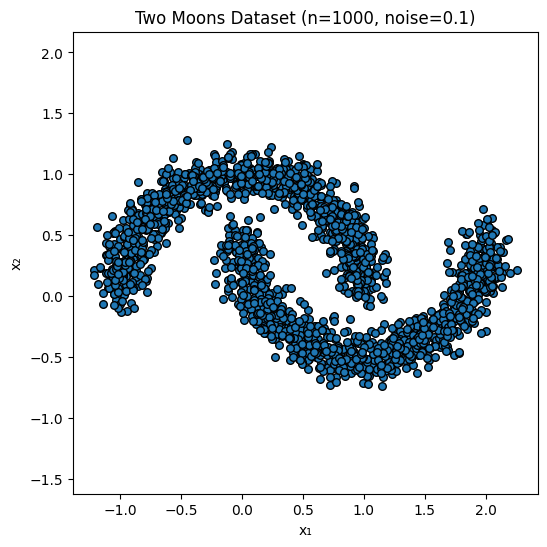

In [2]:
#  Generate data
X, _ = make_moons(n_samples=2000, noise=0.1, random_state=42)
# Inspect shapes and first few rows
print("X shape:", X.shape)    
print("First 5 X:\n", X[:5])
print("Mean of X:", X.mean(axis=0))
print("Std of X:", X.std(axis=0))


plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], edgecolor='k', s=30)
plt.title("Two Moons Dataset (n=1000, noise=0.1)")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.axis("equal")
plt.show()

## Sanity Check: 
Identity of forward and inverse pass is established:

In [3]:
from affine_coupling import AffineCoupling
from affine_coupling import NormalizingFlow
import torch
with torch.no_grad():
    ac = AffineCoupling(size=2, d=1, hidden_size=64) 
    ac.test_identity(tolerance=1e-6)

    nf = NormalizingFlow(input_dim=2, num_layers=4, hidden_size=64)
    nf.test_identity(tolerance=1e-6)

Min: -5.960464477539063e-08, Max: 5.960464477539063e-08
Min: -5.960464477539063e-08, Max: 1.1920928955078125e-07


## Training the Normalizing Flow
Batch Size: 64
Learning Rate: 0.001
Epochs: 100
Optimizer: AdamW
- $\beta_1$: 0.9
- $\beta_2$: 0.999
- Weight decay: 0.01

To get a better understanding of the model's reconstructive capabilities, we calculate the directed Hausdorff-Distance (Taha and Hanbury, 2015) between the generated samples and the original point-cloud. To better understand the performance, we center the reconstruction to standard deviation and mean of original distribution.

Config file not found: config.yaml
Epoch 1, Loss: 176.8872
Hausdorff distance: 1.2293
Epoch 2, Loss: 166.7968
Hausdorff distance: 1.2928
Epoch 3, Loss: 153.6571
Hausdorff distance: 1.1392
Epoch 4, Loss: 148.2281
Hausdorff distance: 0.8245
Epoch 5, Loss: 149.9681
Hausdorff distance: 1.2389
Epoch 6, Loss: 140.6030
Hausdorff distance: 1.0025
Epoch 7, Loss: 145.5672
Hausdorff distance: 0.8977
Epoch 8, Loss: 133.9415
Hausdorff distance: 0.5652
Epoch 9, Loss: 140.1543
Hausdorff distance: 0.6217
Epoch 10, Loss: 132.5176
Hausdorff distance: 0.4319
Epoch 11, Loss: 140.9875
Hausdorff distance: 0.6054
Epoch 12, Loss: 124.6054
Hausdorff distance: 0.5455
Epoch 13, Loss: 132.6081
Hausdorff distance: 0.5130
Epoch 14, Loss: 123.6445
Hausdorff distance: 0.5117
Epoch 15, Loss: 111.7991
Hausdorff distance: 0.5135
Epoch 16, Loss: 107.2945
Hausdorff distance: 0.9045
Epoch 17, Loss: 112.4564
Hausdorff distance: 0.6652
Epoch 18, Loss: 116.5317
Hausdorff distance: 0.9223
Epoch 19, Loss: 103.4584
Hausdorff dis

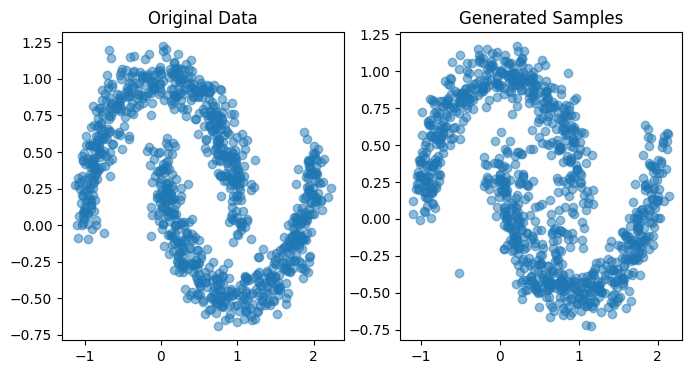

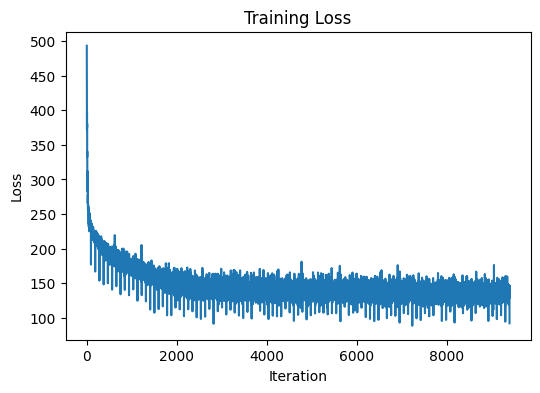

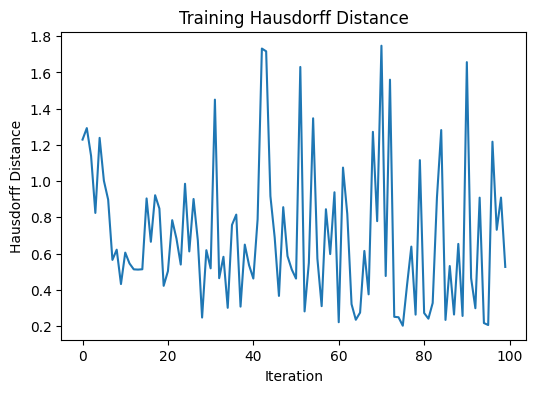

In [4]:
import torch
import torch.utils.data as data
from affine_coupling import NormalizingFlow
from config import Config
from sklearn.datasets import make_moons
from train import train_loop

config = Config('config.yaml')

X, _ = make_moons(n_samples=config.samples, noise=0.1)
x_tensor = torch.tensor(X, dtype=torch.float32)
dataset = data.TensorDataset(x_tensor)
dataloader = data.DataLoader(dataset, batch_size=config.batch_size, shuffle=True)

model = NormalizingFlow(input_dim=config.input_dim, num_layers=config.num_layers, hidden_size=config.hidden_size)
model.train()
model, loss_history, hausdorff_hist = train_loop(config, model, dataloader)

# Sampling and visualization (optional)
with torch.no_grad():
    model.eval()
    z_samples = torch.randn(1000, config.input_dim)
    x_samples = model.inverse(z_samples)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Data")
    # Pick as many random points as there are x_samples
    idx = np.random.choice(X.shape[0], size=x_samples.shape[0], replace=False)
    plt.scatter(X[idx, 0], X[idx, 1], alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.title("Generated Samples")
    plt.scatter(x_samples[:, 0], x_samples[:, 1], alpha=0.5)
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(hausdorff_hist)
    plt.xlabel("Iteration")
    plt.ylabel("Hausdorff Distance")
    plt.title("Training Hausdorff Distance")
    plt.show()




## Alternative Masks
The default masks the first dimension. Here, we switch the dimension, and leave the mask altogether. 

Epoch 1, Loss: 163.3295
Hausdorff distance: 1.3937
Epoch 2, Loss: 150.1926
Hausdorff distance: 1.7571
Epoch 3, Loss: 141.1661
Hausdorff distance: 1.5680
Epoch 4, Loss: 152.7446
Hausdorff distance: 1.2396
Epoch 5, Loss: 136.7962
Hausdorff distance: 0.9662
Epoch 6, Loss: 136.3304
Hausdorff distance: 1.3647
Epoch 7, Loss: 142.3758
Hausdorff distance: 1.2460
Epoch 8, Loss: 137.2917
Hausdorff distance: 1.3590
Epoch 9, Loss: 129.6886
Hausdorff distance: 1.5221
Epoch 10, Loss: 125.0624
Hausdorff distance: 1.6140
Epoch 11, Loss: 124.0467
Hausdorff distance: 0.8869
Epoch 12, Loss: 133.0740
Hausdorff distance: 1.2972
Epoch 13, Loss: 120.0396
Hausdorff distance: 3.8872
Epoch 14, Loss: 111.0909
Hausdorff distance: 1.3485
Epoch 15, Loss: 130.9571
Hausdorff distance: 1.9963
Epoch 16, Loss: 123.5329
Hausdorff distance: 2.4627
Epoch 17, Loss: 125.8496
Hausdorff distance: 2.1643
Epoch 18, Loss: 128.7052
Hausdorff distance: 1.9942
Epoch 19, Loss: 115.4632
Hausdorff distance: 2.0404
Epoch 20, Loss: 121.3

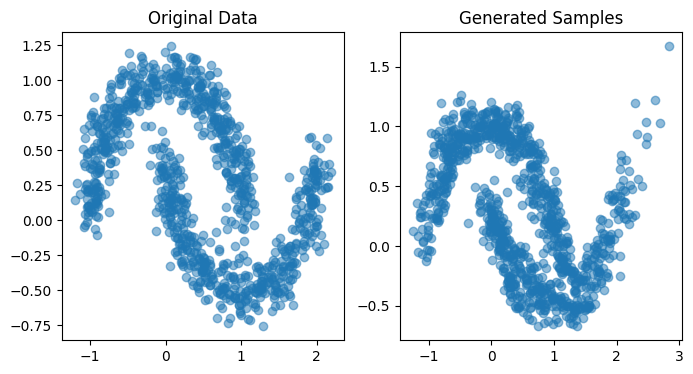

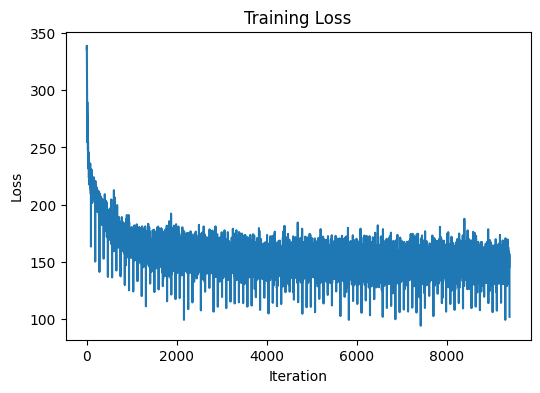

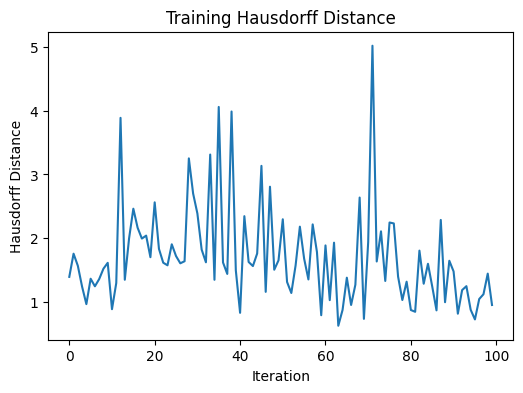

In [5]:
mask = torch.zeros(2)
mask[0] = 1.

model = NormalizingFlow(input_dim=config.input_dim, num_layers=config.num_layers, hidden_size=config.hidden_size, mask=mask)
model.train()
model, loss_history, hausdorff_hist = train_loop(config, model, dataloader)

# Sampling and visualization (optional)
with torch.no_grad():
    model.eval()
    z_samples = torch.randn(1000, config.input_dim)
    x_samples = model.inverse(z_samples)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Data")
    # Pick as many random points as there are x_samples
    idx = np.random.choice(X.shape[0], size=x_samples.shape[0], replace=False)
    plt.scatter(X[idx, 0], X[idx, 1], alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.title("Generated Samples")
    plt.scatter(x_samples[:, 0], x_samples[:, 1], alpha=0.5)
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(hausdorff_hist)
    plt.xlabel("Iteration")
    plt.ylabel("Hausdorff Distance")
    plt.title("Training Hausdorff Distance")
    plt.show()


No mask:

/Users/konradgoldenbaum/Developement/M4ML-2025-Normalizing-Flows/.venv/lib/python3.11/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Epoch 1, Loss: 236.4148
Hausdorff distance: 1.2395
Epoch 2, Loss: 247.2476
Hausdorff distance: 1.3286
Epoch 3, Loss: 252.3586
Hausdorff distance: 1.6989
Epoch 4, Loss: 234.9339
Hausdorff distance: 1.4083
Epoch 5, Loss: 242.4688
Hausdorff distance: 1.7616
Epoch 6, Loss: 236.5756
Hausdorff distance: 1.6025
Epoch 7, Loss: 233.2033
Hausdorff distance: 1.7837
Epoch 8, Loss: 244.3615
Hausdorff distance: 1.3915
Epoch 9, Loss: 236.7581
Hausdorff distance: 1.5561
Epoch 10, Loss: 247.8672
Hausdorff distance: 1.3703
Epoch 11, Loss: 240.3665
Hausdorff distance: 1.1616
Epoch 12, Loss: 251.9655
Hausdorff distance: 1.6983
Epoch 13, Loss: 245.5898
Hausdorff distance: 1.4757
Epoch 14, Loss: 241.4554
Hausdorff distance: 1.1825
Epoch 15, Loss: 242.6340
Hausdorff distance: 1.7663
Epoch 16, Loss: 234.5428
Hausdorff distance: 1.2706
Epoch 17, Loss: 238.7204
Hausdorff distance: 1.4475
Epoch 18, Loss: 236.2972
Hausdorff distance: 1.3664
Epoch 19, Loss: 228.5443
Hausdorff distance: 1.2573
Epoch 20, Loss: 244.7

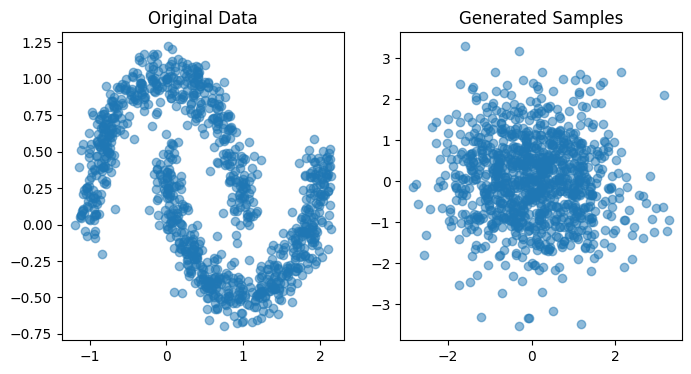

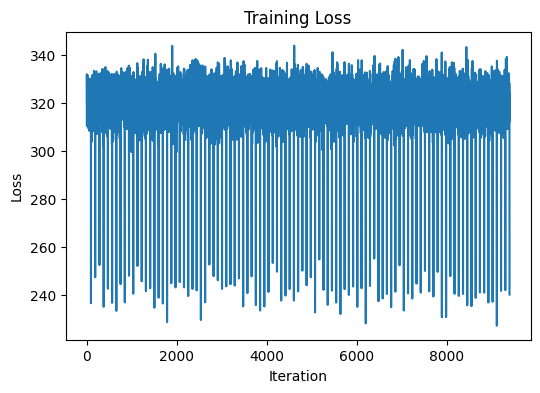

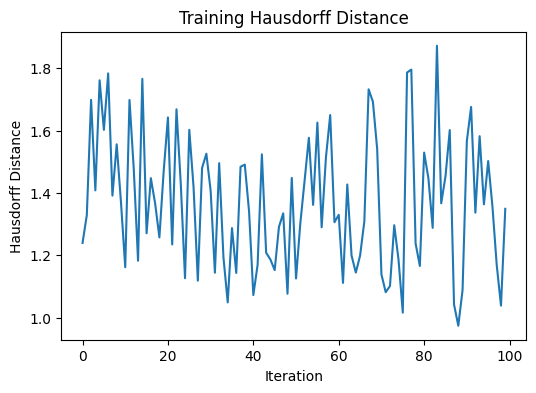

In [6]:
mask = torch.ones(2)

model = NormalizingFlow(input_dim=config.input_dim, num_layers=config.num_layers, hidden_size=config.hidden_size, mask=mask)
model.train()
model, loss_history, hausdorff_hist = train_loop(config, model, dataloader)

# Sampling and visualization (optional)
with torch.no_grad():
    model.eval()
    z_samples = torch.randn(1000, config.input_dim)
    x_samples = model.inverse(z_samples)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Data")
    # Pick as many random points as there are x_samples
    idx = np.random.choice(X.shape[0], size=x_samples.shape[0], replace=False)
    plt.scatter(X[idx, 0], X[idx, 1], alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.title("Generated Samples")
    plt.scatter(x_samples[:, 0], x_samples[:, 1], alpha=0.5)
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(hausdorff_hist)
    plt.xlabel("Iteration")
    plt.ylabel("Hausdorff Distance")
    plt.title("Training Hausdorff Distance")
    plt.show()


All mask:

/Users/konradgoldenbaum/Developement/M4ML-2025-Normalizing-Flows/.venv/lib/python3.11/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Epoch 1, Loss: 199.1461
Hausdorff distance: 1.6773
Epoch 2, Loss: 192.4975
Hausdorff distance: 1.3853
Epoch 3, Loss: 198.6240
Hausdorff distance: 1.2939
Epoch 4, Loss: 191.7132
Hausdorff distance: 1.7459
Epoch 5, Loss: 194.2721
Hausdorff distance: 1.0211
Epoch 6, Loss: 198.1570
Hausdorff distance: 1.2476
Epoch 7, Loss: 192.9951
Hausdorff distance: 1.5431
Epoch 8, Loss: 194.1545
Hausdorff distance: 1.7109
Epoch 9, Loss: 186.0039
Hausdorff distance: 1.3125
Epoch 10, Loss: 185.4344
Hausdorff distance: 1.4760
Epoch 11, Loss: 198.8853
Hausdorff distance: 1.4685
Epoch 12, Loss: 197.3980
Hausdorff distance: 1.0637
Epoch 13, Loss: 198.4431
Hausdorff distance: 1.3077
Epoch 14, Loss: 198.5753
Hausdorff distance: 1.9565
Epoch 15, Loss: 197.0808
Hausdorff distance: 1.2258
Epoch 16, Loss: 193.7501
Hausdorff distance: 1.4244
Epoch 17, Loss: 189.8921
Hausdorff distance: 1.3048
Epoch 18, Loss: 192.2206
Hausdorff distance: 1.3637
Epoch 19, Loss: 191.7219
Hausdorff distance: 1.8183
Epoch 20, Loss: 195.5

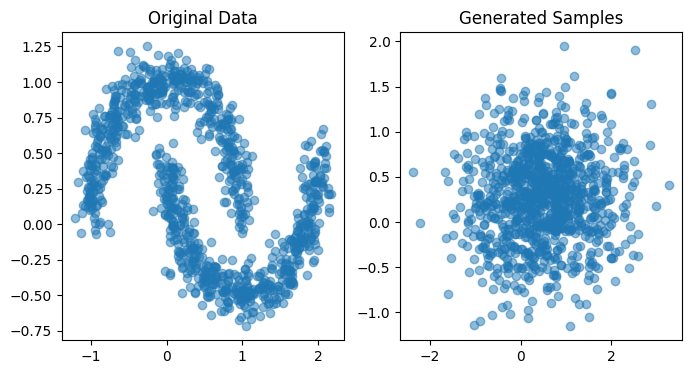

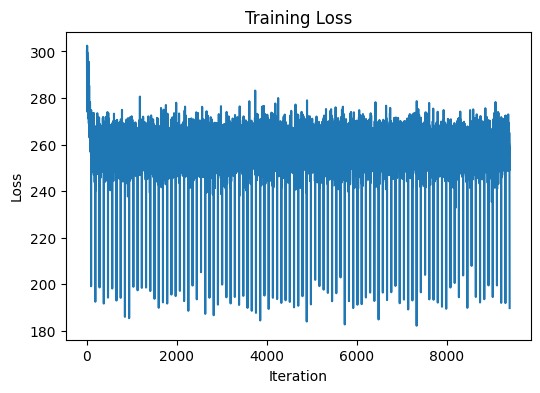

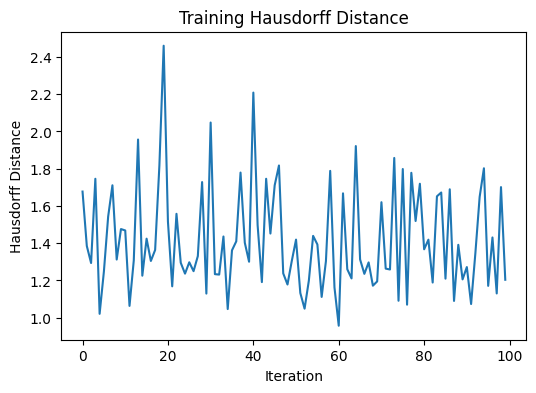

In [7]:
mask = torch.zeros(2)


model = NormalizingFlow(input_dim=config.input_dim, num_layers=config.num_layers, hidden_size=config.hidden_size, mask=mask)
model.train()
model, loss_history, hausdorff_hist = train_loop(config, model, dataloader)

# Sampling and visualization (optional)
with torch.no_grad():
    model.eval()
    z_samples = torch.randn(1000, config.input_dim)
    x_samples = model.inverse(z_samples)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Data")
    # Pick as many random points as there are x_samples
    idx = np.random.choice(X.shape[0], size=x_samples.shape[0], replace=False)
    plt.scatter(X[idx, 0], X[idx, 1], alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.title("Generated Samples")
    plt.scatter(x_samples[:, 0], x_samples[:, 1], alpha=0.5)
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(hausdorff_hist)
    plt.xlabel("Iteration")
    plt.ylabel("Hausdorff Distance")
    plt.title("Training Hausdorff Distance")
    plt.show()
